# Submission 3 — CatBoost with Depth-1 Aggregations + Stability Filtering

Same feature set as Submission 2 (same depth-1 aggregations, same stability filter).
Key differences from Submission 2:
- **CatBoost** instead of LightGBM
- Categorical columns tracked and passed via `cat_features` → CatBoost handles them natively
  (no need to treat them as ordered integers the way LightGBM does)
- Different regularisation: `l2_leaf_reg`, `random_strength` instead of `reg_alpha`/`reg_lambda`
- `auto_class_weights='Balanced'` handles the 30:1 imbalance automatically

Aggregates 4 depth-1 tables:
- `applprev_1` — previous loan applications
- `credit_bureau_a_1` — credit bureau A records
- `credit_bureau_b_1` — credit bureau B records
- `person_1` — person-level demographics

Memory strategy (same as Submission 2):
- All numeric features cast to **float32**
- Intermediate DataFrames deleted + `gc.collect()` after each join
- Predictions saved to `submissions/submission_03_catboost.csv` for ensembling

In [1]:
import glob
import polars as pl
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_auc_score
from scipy.stats import linregress
import matplotlib.pyplot as plt
import gc
import os
import warnings
warnings.filterwarnings('ignore')

DATA = '../data/raw/parquet_files'
OUTPUT = '../submissions'
TRAIN_CUTOFF = 60

print(os.listdir(f'{DATA}/train')[:10])

['train_applprev_1_0.parquet', 'train_applprev_1_1.parquet', 'train_applprev_2.parquet', 'train_base.parquet', 'train_credit_bureau_a_1_0.parquet', 'train_credit_bureau_a_1_1.parquet', 'train_credit_bureau_a_1_2.parquet', 'train_credit_bureau_a_1_3.parquet', 'train_credit_bureau_a_2_0.parquet', 'train_credit_bureau_a_2_1.parquet']


## 1. Aggregate depth-1 tables (lazy — low memory)

Identical to Submission 2.

In [2]:
def aggregate_lazy(pattern: str, name: str) -> pl.DataFrame:
    files = sorted(glob.glob(pattern))
    if not files:
        raise FileNotFoundError(f'No files found: {pattern}')
    print(f'{name}: {len(files)} file(s)')

    ref_schema = None
    for f in files:
        s = pl.read_parquet(f, n_rows=10).schema
        if any(v != pl.Null for v in s.values()):
            ref_schema = s
            break

    parts = []
    for f in files:
        part = pl.read_parquet(f)
        exprs = []
        for c in part.columns:
            if c == 'case_id':
                continue
            dtype = part[c].dtype
            if dtype == pl.Null and ref_schema and c in ref_schema:
                target = ref_schema[c]
                exprs.append(pl.col(c).cast(target if target != pl.Null else pl.Utf8))
            elif dtype in [pl.Float64, pl.Int64, pl.Int32, pl.Int16, pl.Int8]:
                exprs.append(pl.col(c).cast(pl.Float32))
        if exprs:
            part = part.with_columns(exprs)
        parts.append(part)

    df = pl.concat(parts, how='diagonal_relaxed')
    del parts
    gc.collect()

    schema = df.schema
    num_cols = [c for c, dtype in schema.items() if c != 'case_id' and dtype == pl.Float32]
    cat_cols = [c for c, dtype in schema.items() if c != 'case_id' and dtype == pl.Utf8]

    aggs = [pl.len().alias(f'{name}_count').cast(pl.Int32)]
    for col in num_cols:
        aggs += [
            pl.col(col).mean().alias(f'{name}_{col}_mean'),
            pl.col(col).max().alias(f'{name}_{col}_max'),
            pl.col(col).min().alias(f'{name}_{col}_min'),
            pl.col(col).std().alias(f'{name}_{col}_std'),
        ]
    for col in cat_cols:
        aggs.append(pl.col(col).n_unique().cast(pl.Int16).alias(f'{name}_{col}_nunique'))

    result = df.group_by('case_id').agg(aggs)
    del df
    gc.collect()
    print(f'  -> {result.shape}')
    return result

In [3]:
agg_applprev      = aggregate_lazy(f'{DATA}/train/train_applprev_1_*.parquet',        'applprev')
agg_cb_a          = aggregate_lazy(f'{DATA}/train/train_credit_bureau_a_1_*.parquet', 'cb_a')
agg_cb_b          = aggregate_lazy(f'{DATA}/train/train_credit_bureau_b_1.parquet',   'cb_b')
agg_person        = aggregate_lazy(f'{DATA}/train/train_person_1.parquet',            'person')

agg_applprev_test = aggregate_lazy(f'{DATA}/test/test_applprev_1_*.parquet',          'applprev')
agg_cb_a_test     = aggregate_lazy(f'{DATA}/test/test_credit_bureau_a_1_*.parquet',   'cb_a')
agg_cb_b_test     = aggregate_lazy(f'{DATA}/test/test_credit_bureau_b_1.parquet',     'cb_b')
agg_person_test   = aggregate_lazy(f'{DATA}/test/test_person_1.parquet',              'person')

applprev: 2 file(s)
  -> (1221522, 97)
cb_a: 4 file(s)
  -> (1386273, 245)
cb_b: 1 file(s)
  -> (36500, 139)
person: 1 file(s)
  -> (1526659, 51)
applprev: 3 file(s)
  -> (4, 98)
cb_a: 5 file(s)
  -> (5, 245)
cb_b: 1 file(s)
  -> (3, 139)
person: 1 file(s)
  -> (6, 51)


## 2. Load depth-0 tables and join everything

In [4]:
def cast_static(df: pl.DataFrame) -> pl.DataFrame:
    return df.with_columns([
        pl.col(c).cast(pl.Float32)
        for c in df.columns
        if df[c].dtype in [pl.Float64, pl.Int64, pl.Int32]
        and c not in ('case_id', 'target', 'WEEK_NUM', 'MONTH')
    ])

base      = pl.read_parquet(f'{DATA}/train/train_base.parquet')
static0   = pl.scan_parquet(sorted(glob.glob(f'{DATA}/train/train_static_0_*.parquet'))).collect().pipe(cast_static)
static_cb = pl.read_parquet(f'{DATA}/train/train_static_cb_0.parquet').pipe(cast_static)

test_base      = pl.read_parquet(f'{DATA}/test/test_base.parquet')
test_static0   = pl.scan_parquet(sorted(glob.glob(f'{DATA}/test/test_static_0_*.parquet'))).collect().pipe(cast_static)
test_static_cb = pl.read_parquet(f'{DATA}/test/test_static_cb_0.parquet').pipe(cast_static)

def build(base_df, s0, scb, aggs):
    df = base_df.join(s0, on='case_id', how='left').join(scb, on='case_id', how='left')
    for agg in aggs:
        df = df.join(agg, on='case_id', how='left')
    return df

df   = build(base, static0, static_cb, [agg_applprev, agg_cb_a, agg_cb_b, agg_person])
test = build(test_base, test_static0, test_static_cb, [agg_applprev_test, agg_cb_a_test, agg_cb_b_test, agg_person_test])

del static0, static_cb, test_static0, test_static_cb
del agg_applprev, agg_cb_a, agg_cb_b, agg_person
del agg_applprev_test, agg_cb_a_test, agg_cb_b_test, agg_person_test
gc.collect()

print(f'Train: {df.shape}')
print(f'Test:  {test.shape}')

Train: (1526659, 752)
Test:  (10, 752)


## 3. Preprocessing (CatBoost-aware)

Key difference from the LightGBM notebook:
- String columns are filled with `"NA"` for nulls, then **integer-encoded**
- We track which columns are categorical (`cat_cols`) so CatBoost can receive them
  via `cat_features` — it will treat them as unordered categories rather than numeric values,
  which is more correct and often improves performance vs LightGBM's integer treatment.

In [5]:
DROP_COLS = ['case_id', 'date_decision', 'MONTH', 'WEEK_NUM', 'target']
TEST_DROP = ['case_id', 'date_decision', 'MONTH', 'WEEK_NUM']

def preprocess_catboost(df: pl.DataFrame, drop_cols: list):
    # Date columns → days-since-epoch integer
    date_cols = [c for c in df.columns if c.endswith('_D') and c not in drop_cols]
    for col in date_cols:
        df = df.with_columns(
            pl.col(col).str.to_date(strict=False).cast(pl.Int32).alias(col)
        )

    # Categorical/string columns: fill null with 'NA', then integer-encode.
    # We fill null BEFORE cast so 'NA' gets its own category code (no NaN in output).
    # CatBoost will receive these as cat_features indices and treat them unordered.
    cat_col_names = [c for c in df.columns if df[c].dtype == pl.Utf8 and c not in drop_cols]
    for col in cat_col_names:
        df = df.with_columns(
            pl.col(col).fill_null('NA').cast(pl.Categorical).to_physical().cast(pl.Int16).alias(col)
        )

    df = df.drop([c for c in drop_cols if c in df.columns])
    surviving_cat_cols = [c for c in cat_col_names if c in df.columns]
    return df, surviving_cat_cols

week_num = df['WEEK_NUM'].to_numpy()
y = df['target'].to_numpy()

X_df,      cat_cols      = preprocess_catboost(df,   DROP_COLS)
X_test_df, cat_cols_test = preprocess_catboost(test, TEST_DROP)
del df, test
gc.collect()

feature_cols = [c for c in X_df.columns if c in X_test_df.columns]
cat_cols     = [c for c in cat_cols if c in feature_cols]
X_df         = X_df.select(feature_cols)
X_test_df    = X_test_df.select(feature_cols)

print(f'Features before stability filter: {len(feature_cols)}')
print(f'Categorical columns: {len(cat_cols)}')

Features before stability filter: 747
Categorical columns: 49


## 4. Stability-first feature filtering

Same as Submission 2: compute coefficient of variation of per-week means on training weeks,
drop the top 10% most temporally drifting numeric features.

In [6]:
train_mask = week_num <= TRAIN_CUTOFF

numeric_cols = [
    c for c in X_df.columns
    if X_df[c].dtype in [pl.Float32, pl.Float64, pl.Int32, pl.Int16, pl.Int8]
    and c not in cat_cols
]

# Convert week_num to list to avoid any numpy ndarray handling differences in
# pl.Series across Polars versions. Then filter via pl.col() instead of a mask.
df_wk = (
    X_df.select(numeric_cols)
    .with_columns(pl.Series(name='WEEK_NUM', values=week_num.tolist()))
    .filter(pl.col('WEEK_NUM') <= TRAIN_CUTOFF)
)
weekly_means = df_wk.group_by('WEEK_NUM').agg([pl.col(c).mean() for c in numeric_cols]).sort('WEEK_NUM')

drift = {}
for col in numeric_cols:
    vals = weekly_means[col].drop_nulls().to_numpy()
    if len(vals) < 5 or np.abs(vals.mean()) < 1e-9:
        drift[col] = 0.0
    else:
        drift[col] = vals.std() / np.abs(vals.mean())

del df_wk, weekly_means
gc.collect()

drift_df = pl.DataFrame({'feature': list(drift.keys()), 'drift': list(drift.values())}).sort('drift', descending=True)
n_drop = max(1, int(len(drift_df) * 0.10))
unstable = set(drift_df.head(n_drop)['feature'].to_list())
stable_features = [c for c in feature_cols if c not in unstable]
cat_cols_stable = [c for c in cat_cols if c in stable_features]

print(f'Dropped {len(unstable)} unstable features, {len(stable_features)} remaining')
print(f'Categorical features remaining: {len(cat_cols_stable)}')
print('Top 10 most unstable (dropped):')
print(drift_df.head(10))

Dropped 69 unstable features, 678 remaining
Categorical features remaining: 49
Top 10 most unstable (dropped):
shape: (10, 2)
┌─────────────────────────────────┬───────────┐
│ feature                         ┆ drift     │
│ ---                             ┆ ---       │
│ str                             ┆ f32       │
╞═════════════════════════════════╪═══════════╡
│ mindbdtollast24m_4525191P       ┆ 17.570129 │
│ mindbddpdlast24m_3658935P       ┆ 9.613837  │
│ forweek_1077L                   ┆ 7.549834  │
│ cb_b_installmentamount_644A_st… ┆ 7.199797  │
│ cb_b_dpd_733P_max               ┆ 7.041833  │
│ cb_b_dpd_733P_std               ┆ 7.009432  │
│ cb_b_dpd_733P_mean              ┆ 6.962499  │
│ cb_b_installmentamount_644A_ma… ┆ 6.43807   │
│ cb_a_numberofoutstandinstls_52… ┆ 6.051119  │
│ cb_a_numberofoutstandinstls_52… ┆ 6.017422  │
└─────────────────────────────────┴───────────┘


In [7]:
# Convert to pandas (NOT numpy) so per-column dtypes are preserved:
# - numeric columns stay float32
# - categorical columns (integer-encoded) stay int16
# CatBoost Pool needs this distinction — passing a uniform float numpy array with
# cat_features set raises "data is numpy array of floating point numerical type".
X      = X_df.select(stable_features).to_pandas()
X_test = X_test_df.select(stable_features).to_pandas()
del X_df, X_test_df
gc.collect()

print(f'Feature matrix: {X.shape}, Test: {X_test.shape}')
print(f'Categorical features: {len(cat_cols_stable)}')
print(f'Dtypes sample: {X.dtypes.value_counts().to_dict()}')

Feature matrix: (1526659, 678), Test: (10, 678)
Categorical features: 49
Dtypes sample: {dtype('float32'): 539, dtype('int16'): 74, dtype('float64'): 58, dtype('O'): 5, dtype('bool'): 1, dtype('int32'): 1}


## 5. Gini stability metric

In [8]:
def gini_stability(week_nums, targets, preds):
    weeks = np.unique(week_nums)
    weekly_gini = []
    for w in weeks:
        mask = week_nums == w
        if targets[mask].sum() == 0:
            continue
        weekly_gini.append(2 * roc_auc_score(targets[mask], preds[mask]) - 1)
    weekly_gini = np.array(weekly_gini)
    mean_gini = weekly_gini.mean()
    slope, intercept, *_ = linregress(np.arange(len(weekly_gini)), weekly_gini)
    residuals = weekly_gini - (intercept + slope * np.arange(len(weekly_gini)))
    return mean_gini + 88.0 * min(0, slope) - 0.5 * residuals.std(), mean_gini, slope, residuals.std(), weekly_gini

## 6. Time-based split + build CatBoost Pools

`Pool` is CatBoost's data container — it stores the feature matrix alongside the
`cat_features` indices so the model always knows which columns are categorical,
both during training and prediction.

In [9]:
val_mask = week_num > TRAIN_CUTOFF

# X is a pandas DataFrame now — boolean mask indexing works the same
X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
week_val = week_num[val_mask]

print(f'Train: {X_train.shape[0]:,} ({y_train.mean():.3%} pos)')
print(f'Val:   {X_val.shape[0]:,} ({y_val.mean():.3%} pos)')

# Pass cat_features by column NAME instead of index — more robust and works
# directly with pandas DataFrames.
train_pool = Pool(X_train, label=y_train, cat_features=cat_cols_stable)
val_pool   = Pool(X_val,   label=y_val,   cat_features=cat_cols_stable)

params = {
    'iterations': 1000,
    'learning_rate': 0.05,
    'depth': 6,
    'l2_leaf_reg': 3.0,
    'random_strength': 1.0,
    'border_count': 128,
    'auto_class_weights': 'Balanced',
    'eval_metric': 'AUC',
    'random_seed': 42,
    'task_type': 'GPU',   # use NVIDIA GPU; CatBoost bundles its own CUDA runtime
    'devices': '0',       # first GPU. Change to '0:1' for multi-GPU, etc.
    'verbose': 100,
}

model = CatBoostClassifier(**params)
model.fit(
    train_pool,
    eval_set=val_pool,
    early_stopping_rounds=50,
)

print(f'\nBest iteration: {model.best_iteration_}')

Train: 1,235,013 (3.258% pos)
Val:   291,646 (2.661% pos)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7554017	best: 0.7554017 (0)	total: 635ms	remaining: 10m 34s
100:	test: 0.8283107	best: 0.8283107 (100)	total: 27.2s	remaining: 4m 2s
200:	test: 0.8394521	best: 0.8394521 (200)	total: 53.4s	remaining: 3m 32s
300:	test: 0.8448038	best: 0.8448038 (300)	total: 1m 19s	remaining: 3m 4s
400:	test: 0.8480384	best: 0.8480384 (400)	total: 1m 45s	remaining: 2m 37s
500:	test: 0.8500416	best: 0.8500416 (500)	total: 2m 11s	remaining: 2m 10s
600:	test: 0.8507476	best: 0.8509185 (587)	total: 2m 35s	remaining: 1m 43s
700:	test: 0.8517202	best: 0.8517202 (700)	total: 3m	remaining: 1m 17s
800:	test: 0.8526687	best: 0.8526687 (800)	total: 3m 26s	remaining: 51.4s
900:	test: 0.8531758	best: 0.8531903 (893)	total: 3m 52s	remaining: 25.6s
bestTest = 0.8532560468
bestIteration = 924
Shrink model to first 925 iterations.

Best iteration: 924


## 7. Evaluate

Validation AUC:        0.8533
Gini stability score:  0.6723
  Mean weekly Gini:    0.6920
  Trend slope:         0.002285
  Residual std:        0.0393


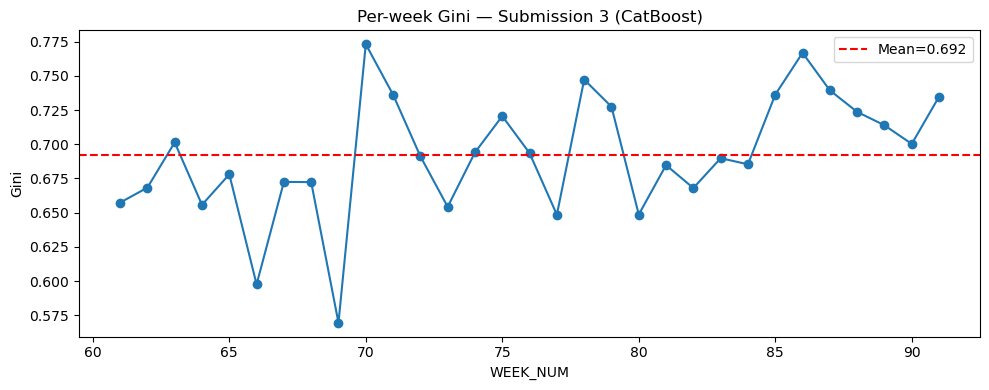

In [10]:
val_preds = model.predict_proba(val_pool)[:, 1]
auc = roc_auc_score(y_val, val_preds)
score, mean_gini, slope, resid_std, weekly_gini = gini_stability(week_val, y_val, val_preds)

print(f'Validation AUC:        {auc:.4f}')
print(f'Gini stability score:  {score:.4f}')
print(f'  Mean weekly Gini:    {mean_gini:.4f}')
print(f'  Trend slope:         {slope:.6f}')
print(f'  Residual std:        {resid_std:.4f}')

valid_weeks = [w for w in np.unique(week_val) if y_val[week_val == w].sum() > 0]
plt.figure(figsize=(10, 4))
plt.plot(valid_weeks, weekly_gini, marker='o', linewidth=1.5)
plt.axhline(mean_gini, color='red', linestyle='--', label=f'Mean={mean_gini:.3f}')
plt.xlabel('WEEK_NUM')
plt.ylabel('Gini')
plt.title('Per-week Gini — Submission 3 (CatBoost)')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Feature importance

Top 20 features:
shape: (20, 2)
┌───────────────────────────────┬────────────┐
│ feature                       ┆ importance │
│ ---                           ┆ ---        │
│ str                           ┆ f64        │
╞═══════════════════════════════╪════════════╡
│ dateofbirth_337D              ┆ 6.493169   │
│ firstdatedue_489D             ┆ 4.957759   │
│ avgdpdtolclosure24_3658938P   ┆ 3.165417   │
│ cb_a_dpdmaxdateyear_596T_mean ┆ 2.176252   │
│ pmtnum_254L                   ┆ 2.075114   │
│ …                             ┆ …          │
│ lastrejectcommoditycat_161M   ┆ 1.039897   │
│ pmtssum_45A                   ┆ 1.024902   │
│ cb_a_dpdmaxdateyear_896T_std  ┆ 1.018672   │
│ days120_123L                  ┆ 1.017337   │
│ interestrate_311L             ┆ 0.96889    │
└───────────────────────────────┴────────────┘


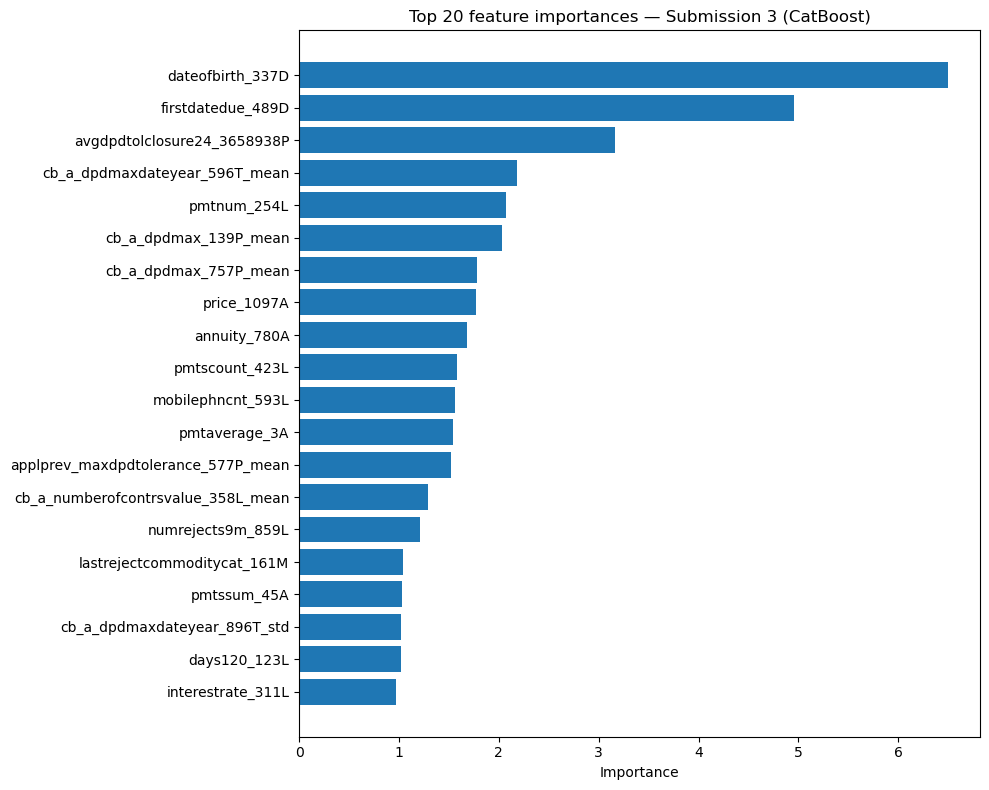

In [11]:
importance = pl.DataFrame({
    'feature': stable_features,
    'importance': model.get_feature_importance(train_pool)
}).sort('importance', descending=True)

print('Top 20 features:')
print(importance.head(20))

top20 = importance.head(20)
plt.figure(figsize=(10, 8))
plt.barh(top20['feature'].to_list()[::-1], top20['importance'].to_list()[::-1])
plt.xlabel('Importance')
plt.title('Top 20 feature importances — Submission 3 (CatBoost)')
plt.tight_layout()
plt.show()

## 9. Retrain on full data & save predictions

Retrain using `best_iteration_` found during CV, then save both the standalone submission
and the raw probability array for ensembling with the LightGBM predictions.

In [12]:
import pandas as pd

# Defensive: when the test set has only 10 rows, any string column where all 10
# values are null gets pl.Null dtype in Polars (not pl.Utf8) and skips the
# integer-encoding step. It then arrives in pandas as `object` dtype with
# `None` values, which CatBoost rejects in cat_features. Force-encode here.
for c in cat_cols_stable:
    if X_test[c].dtype == 'object' or X_test[c].isna().any():
        X_test[c] = X_test[c].fillna('NA').astype('category').cat.codes.astype('int16')

full_pool = Pool(X, label=y, cat_features=cat_cols_stable)
test_pool = Pool(X_test,      cat_features=cat_cols_stable)

final_model = CatBoostClassifier(**{**params, 'iterations': model.best_iteration_})
final_model.fit(full_pool)

test_preds = final_model.predict_proba(test_pool)[:, 1]

os.makedirs(OUTPUT, exist_ok=True)

# Standalone submission
submission = pl.DataFrame({
    'case_id': test_base['case_id'],
    'score': test_preds
})
submission.write_csv(f'{OUTPUT}/submission_03_catboost.csv')
print(f'Saved {len(submission):,} predictions to submission_03_catboost.csv')

# Raw probabilities for ensembling
np.save(f'{OUTPUT}/catboost_test_preds.npy', test_preds)
print('Saved raw probabilities to catboost_test_preds.npy')
print(submission.describe())

Default metric period is 5 because AUC is/are not implemented for GPU


0:	total: 488ms	remaining: 7m 30s
100:	total: 32.3s	remaining: 4m 22s
200:	total: 1m 2s	remaining: 3m 44s
300:	total: 1m 32s	remaining: 3m 11s
400:	total: 2m 2s	remaining: 2m 39s
500:	total: 2m 31s	remaining: 2m 8s
600:	total: 3m 4s	remaining: 1m 39s
700:	total: 3m 51s	remaining: 1m 13s
800:	total: 4m 28s	remaining: 41.3s
900:	total: 5m 7s	remaining: 7.86s
923:	total: 5m 16s	remaining: 0us
Saved 10 predictions to submission_03_catboost.csv
Saved raw probabilities to catboost_test_preds.npy
shape: (9, 3)
┌────────────┬───────────┬──────────┐
│ statistic  ┆ case_id   ┆ score    │
│ ---        ┆ ---       ┆ ---      │
│ str        ┆ f64       ┆ f64      │
╞════════════╪═══════════╪══════════╡
│ count      ┆ 10.0      ┆ 10.0     │
│ null_count ┆ 0.0       ┆ 0.0      │
│ mean       ┆ 57592.4   ┆ 0.34853  │
│ std        ┆ 42.253731 ┆ 0.184805 │
│ min        ┆ 57543.0   ┆ 0.066633 │
│ 25%        ┆ 57551.0   ┆ 0.151842 │
│ 50%        ┆ 57630.0   ┆ 0.369737 │
│ 75%        ┆ 57632.0   ┆ 0.483326